# Scoring-modell
Träna och utvärdera regressionsmodeller på CLIP-embeddings → log(score).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error
import joblib

embeddings = np.load('../data/processed/embeddings.npy')
df = pd.read_csv('../data/processed/clustered.csv')
y = np.log1p(df['score'].values)

X_train, X_test, y_train, y_test, df_train, df_test = train_test_split(
    embeddings, y, df, test_size=0.2, random_state=42
)
print(X_train.shape, X_test.shape)

(1148, 512) (287, 512)


In [2]:
import sys; sys.path.insert(0, '..')
from src.models.scorer import train_regression, build_targets

_, y_clf, _ = build_targets(df)
results, _, _ = train_regression(embeddings, y)
print(results)

=== Regression ===
  ridge   R²=-0.3126  MAE=1.3080
  rf      R²=0.1011  MAE=1.0585
  gbm     R²=0.0449  MAE=1.0654

  Best: rf (R²=0.1011)
{'ridge': {'r2': -0.3126, 'mae': 1.308}, 'rf': {'r2': 0.1011, 'mae': 1.0585}, 'gbm': {'r2': 0.0449, 'mae': 1.0654}}


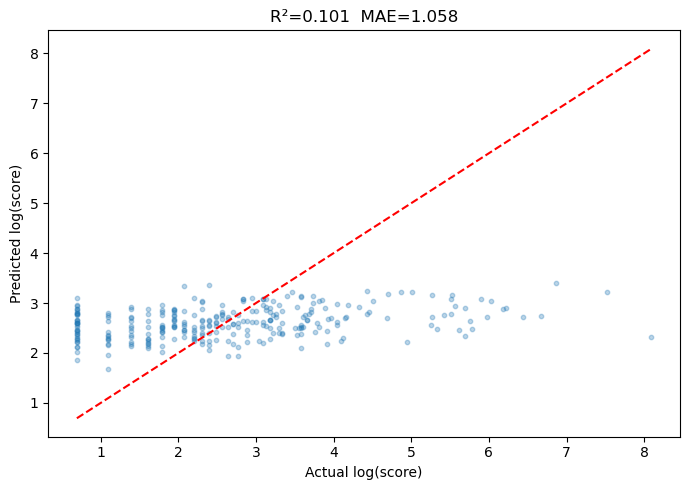

In [3]:
model = joblib.load('../data/models/scorer.pkl')
preds = model.predict(X_test)

plt.figure(figsize=(7, 5))
plt.scatter(y_test, preds, alpha=0.3, s=10)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual log(score)')
plt.ylabel('Predicted log(score)')
plt.title(f'R²={r2_score(y_test, preds):.3f}  MAE={mean_absolute_error(y_test, preds):.3f}')
plt.tight_layout()

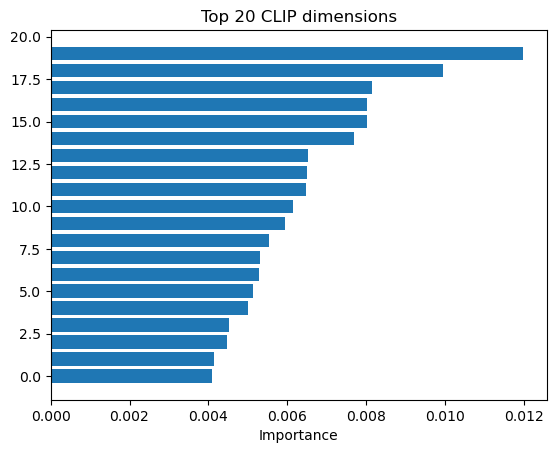

In [4]:
# Feature importance — vilka CLIP-dimensioner är viktigast?
# (fungerar för RF/GBM, inte Ridge)
try:
    importances = model.feature_importances_
    top_idx = np.argsort(importances)[-20:]
    plt.barh(range(20), importances[top_idx])
    plt.xlabel('Importance')
    plt.title('Top 20 CLIP dimensions')
except AttributeError:
    print('Ridge: kolla coefficients istället')
    coefs = model.named_steps['model'].coef_
    top_idx = np.argsort(np.abs(coefs))[-20:]
    plt.barh(range(20), coefs[top_idx])
    plt.xlabel('Coefficient')
    plt.title('Top 20 Ridge coefficients')